In [120]:
df2 = pd.read_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/sophia.csv")
print(df.shape, df2.shape)


(184710, 10) (198010, 14)


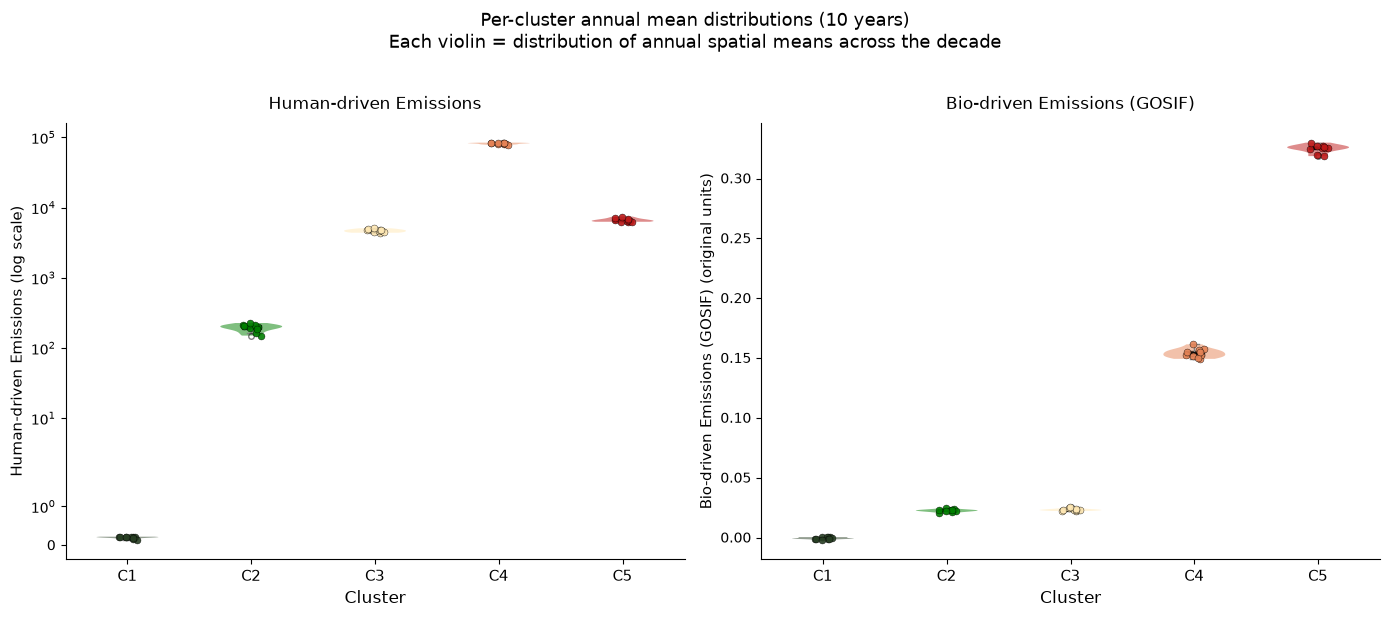

In [105]:
"""
Plot 1 & 2: Per-cluster emission and GOSIF distributions across 10 years.

Methodology:
  - For each (cluster, year): compute the spatial mean across all lat-lon points.
  - Plot the distribution of these 10 annual means per cluster as violin + boxplot.
  - This separates spatial averaging (within a year) from temporal variability (across years).

Usage:
  python plot_distributions.py --csv path/to/your/data.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\darja\Complexity72h\complexity72_2026\clustering\co-occurrence-clusters.csv")

COMPONENT_COLS = [c for c in df.columns if c.startswith("component_")]
N_CLUSTERS = len(COMPONENT_COLS)

# ── Melt to long format: one row per (lat, lon, time, cluster_id) ─────────────
df_long = df.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
# Keep only rows where the point belongs to the cluster
df_long = df_long[df_long["member"] == 1].copy()
df_long["cluster_id"] = df_long["component"].str.extract(r"(\d+)$").astype(int)

# ── Step 1: spatial mean per (cluster, year) ──────────────────────────────────
annual_means = (
    df_long.groupby(["cluster_id", "time"])[["emission", "gosif"]]
    .mean()
    .reset_index()
)

clusters = sorted(annual_means["cluster_id"].unique())
n = len(clusters)

# ── Custom Cluster Colors ─────────────────────────────────────────────────────
# Maps C0 -> #283F24, C1 -> green, C2 -> #FFE8B4, etc.
cluster_colors = ["#283F24", "green", "#FFE8B4", "#E68457", "#BE1A1A"]

# ── Plotting ──────────────────────────────────────────────────────────────────
VARIABLES = [
    ("emission", "Human-driven Emissions", True),  # True = use log scale
    ("gosif",    "Bio-driven Emissions (GOSIF)", False), # False = linear scale
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle(
    "Per-cluster annual mean distributions (10 years)\n"
    "Each violin = distribution of annual spatial means across the decade",
    fontsize=13, y=1.02,
)

for ax, (var, label, use_log) in zip(axes, VARIABLES):
    data_per_cluster = [
        annual_means.loc[annual_means["cluster_id"] == c, var].values
        for c in clusters
    ]

    # Create the violins
    parts = ax.violinplot(
        data_per_cluster,
        positions=range(n),
        showmedians=False,
        showextrema=False,
    )
    
    # Color each violin body based on its corresponding cluster color
    for i, pc in enumerate(parts["bodies"]):
        c_color = cluster_colors[i % len(cluster_colors)]
        pc.set_facecolor(c_color)
        pc.set_alpha(0.5)
        pc.set_edgecolor("none")

    # Overlay boxplots individually to assign distinct colors per cluster
    for i, vals in enumerate(data_per_cluster):
        c_color = cluster_colors[i % len(cluster_colors)]
        
        bp = ax.boxplot(
            [vals],
            positions=[i],
            widths=0.15,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            boxprops=dict(facecolor=c_color, alpha=0.7),
            whiskerprops=dict(color="gray"),
            capprops=dict(color="gray"),
            flierprops=dict(marker="o", color=c_color, alpha=0.5, markersize=4),
        )

    # Scatter the 10 annual means so individual years are visible
    for i, vals in enumerate(data_per_cluster):
        c_color = cluster_colors[i % len(cluster_colors)]
        jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, color=c_color, s=25, alpha=0.9, zorder=5, edgecolor="black", linewidths=0.3)

    # Scale Configuration
    if use_log:
        ax.set_yscale("symlog")
        ax.set_ylabel(f"{label} (log scale)", fontsize=11)
        # Cleaner grid lines for log scale major grid
        #ax.grid(axis="y", which="both", linestyle="--", alpha=0.2)
    else:
        ax.set_ylabel(f"{label} (original units)", fontsize=11)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style="sci", axis="y", scilimits=(-3, 3))
        #ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.set_xticks(range(n))
    ax.set_xticklabels([f"C{c}" for c in clusters], fontsize=11)
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_title(label, fontsize=12, pad=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#plt.savefig("cluster_distributions.png", dpi=150, bbox_inches="tight")
#print("Saved: cluster_distributions.png")
plt.show()

In [ ]:

"""
Plot 3: Geographic map of clusters colored by normalized dominance:
  (emission_norm - gosif_norm), where both are min-max normalized [0,1]
  using their global range.
 
Aggregation:
  For each cluster, emission and gosif are averaged across ALL years AND all
  lat-lon points belonging to that cluster (i.e. a single grand mean per
  cluster). This gives one representative value per cluster for the full
  10-year period before any normalisation or differencing.
 
Color scale:
  - Red   → human emission dominated (dominance close to +1)
  - Green → bio (GOSIF) dominated    (dominance close to -1)
  - Gray  → clusters where BOTH grand-mean emission AND gosif == 0.0
            Gray is enforced via cmap.set_bad(), so it is structurally
            guaranteed: null-cluster points are assigned NaN dominance and
            matplotlib routes them to the 'bad' color regardless of any
            downstream logic.
 
Dependencies:
  pip install pandas numpy matplotlib geopandas
 
Natural Earth borders are fetched automatically via geopandas. On first run
geopandas will download the data; subsequent runs use a local cache.
 
Usage:
  python plot_map.py --csv path/to/your/data.csv
  python plot_map.py --csv path/to/your/data.csv --extent -10 40 35 72
"""
 
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import geopandas as gpd
 
# ── Natural Earth borders: works across geopandas versions ───────────────────
def load_world():
    """
    Load Natural Earth country borders.
    geopandas < 1.0  → bundled naturalearth_lowres
    geopandas >= 1.0 → bundled dataset removed; use geodatasets or direct URL
    """
    try:
        # geopandas < 1.0
        return gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except AttributeError:
        pass
 
    try:
        # geopandas >= 1.0 with geodatasets installed
        from geodatasets import get_path
        return gpd.read_file(get_path("naturalearth.land"))
    except Exception:
        pass
 
    # Universal fallback: download directly from Natural Earth
    url = (
        "https://naciscdn.org/naturalearth/110m/cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    print(f"Downloading Natural Earth borders from {url} ...")
    return gpd.read_file(url)
 
 
COMPONENT_COLS = [c for c in df.columns if c.startswith("component_")]
 
# ── Melt: one row per (lat, lon, time, cluster_id) for membership == 1 ────────
df_long = df.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df_long = df_long[df_long["member"] == 1].copy()
df_long["cluster_id"] = df_long["component"].str.extract(r"(\d+)$").astype(int)
 
# ── Per-cluster grand mean ────────────────────────────────────────────────────
# Average emission and gosif across ALL years AND all lat-lon points per cluster.
# Result: one scalar per (cluster, variable) representing the full 10-year period.
cluster_stats = (
    df_long.groupby("cluster_id")[["emission", "gosif"]]
    .mean()
    .reset_index()
)
 
# ── Null cluster: both grand-mean emission AND gosif == 0.0 ──────────────────
# These receive NaN dominance so matplotlib routes them to cmap.set_bad() (gray).
# This is structural: gray is guaranteed by the colormap, not by a conditional
# scatter branch that could silently fail if the is_null flag were wrong.
null_mask     = (cluster_stats["emission"] == 0.0) & (cluster_stats["gosif"] == 0.0)
null_clusters = set(cluster_stats.loc[null_mask, "cluster_id"])
 
# ── Min-max normalisation over non-null clusters only ────────────────────────
active = cluster_stats[~null_mask]
 
def safe_minmax(series, xmin, xmax):
    if xmax == xmin:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - xmin) / (xmax - xmin)
 
e_min, e_max = active["emission"].min(), active["emission"].max()
g_min, g_max = active["gosif"].min(),    active["gosif"].max()
 
cluster_stats["emission_norm"] = safe_minmax(cluster_stats["emission"], e_min, e_max)
cluster_stats["gosif_norm"]    = safe_minmax(cluster_stats["gosif"],    g_min, g_max)
 
# Dominance: +1 → fully emission-dominated, −1 → fully gosif-dominated
# Null clusters get NaN → rendered as gray via cmap.set_bad()
cluster_stats["dominance"] = cluster_stats["emission_norm"] - cluster_stats["gosif_norm"]
cluster_stats.loc[null_mask, "dominance"] = np.nan
 
dom_map = dict(zip(cluster_stats["cluster_id"], cluster_stats["dominance"]))
 
# ── One row per unique lat-lon ────────────────────────────────────────────────
point_cluster = (
    df_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)
point_cluster["dominance"] = point_cluster["cluster_id"].map(dom_map)
# NaN dominance = null cluster; no need to split into separate DataFrames —
# the colormap handles it structurally via set_bad().
 # ── Load world borders and clip to extent ─────────────────────────────────────
world = load_world()
world = world.cx[lon_min:lon_max, lat_min:lat_max]   # spatial clip
 

Saved: cluster_map.png with new discriminative colors


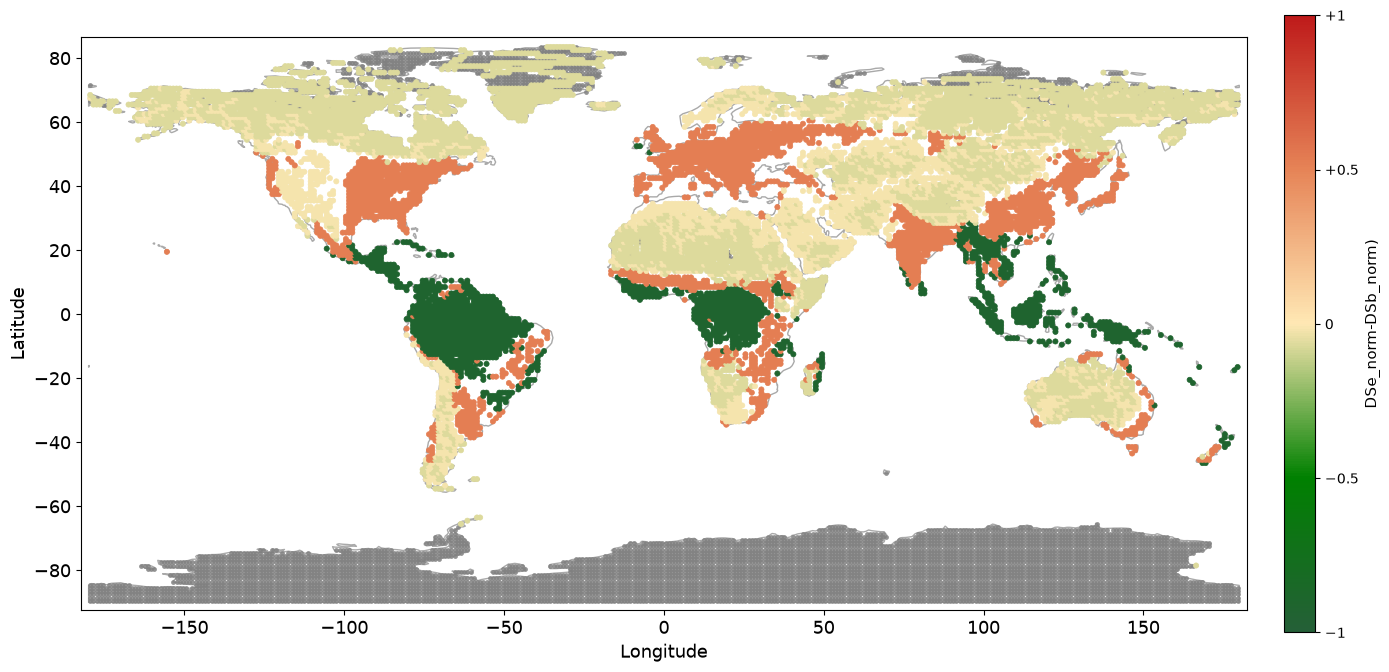

In [137]:
# Regenerate the map with new colors
import importlib
import sys
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# ── Muted diverging colormap: soft green (GOSIF) ↔ soft brown (Emission) ────

# Create custom colormap with more discriminative but still muted colors
NULL_GRAY = "gray"
colors_muted = ["#255F38", "green", "#FFE8B4", "#E68457", "#BE1A1A"]
cmap = mcolors.LinearSegmentedColormap.from_list("muted_div", colors_muted)
cmap.set_bad(color=NULL_GRAY)
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Force re-execution by re-running the full map cell
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("white")

world.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgray",
    linewidth=1,
    zorder=1,
)

# ── UPDATED SCATTER SECTION ──────────────────────────────────────────────────
# Separate valid data points from the null/NaN points so scatter can render both
valid_mask = point_cluster["dominance"].notna()
null_mask = ~valid_mask

# 1. Plot the valid points using the colormap
sc = ax.scatter(
    point_cluster.loc[valid_mask, "lon"], 
    point_cluster.loc[valid_mask, "lat"],
    c=point_cluster.loc[valid_mask, "dominance"],
    cmap=cmap, norm=norm,
    s=14, alpha=1,
    zorder=4, linewidths=0.5,
)

# 2. Plot the null points explicitly using your NULL_GRAY color
if null_mask.any():
    ax.scatter(
        point_cluster.loc[null_mask, "lon"], 
        point_cluster.loc[null_mask, "lat"],
        color=NULL_GRAY,
        s=12, alpha=0.85,
        zorder=3, linewidths=0,
    )
# ─────────────────────────────────────────────────────────────────────────────

cbar = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax, orientation="vertical", fraction=0.025, pad=0.03,
)
cbar.set_label(
    r"DSe_norm-DSb_norm)",
    fontsize=11,
)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels([
    "−1 ",
    "−0.5",
    "0",
    "+0.5",
    "+1",
])

#if null_clusters:
#    null_patch = mpatches.Patch(facecolor=NULL_GRAY, label="Null cluster (emission_norm = gosif_norm = 0)")
#    ax.legend(handles=[null_patch], loc="lower left", fontsize=10, framealpha=0.85)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude",  fontsize=13)


#ax.set_title(
#    "Cluster dominance map: human emissions vs. bio (GOSIF)\n"
#    r""
#    "  |  min-max normalised globally",
#    fontsize=12,
#)

#ax.grid(True, linewidth=0.3, color="lightgray", alpha=0.4, linestyle="--")
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig("cluster_map.png", dpi=150, bbox_inches="tight")
print("Saved: cluster_map.png with new discriminative colors")
plt.show()

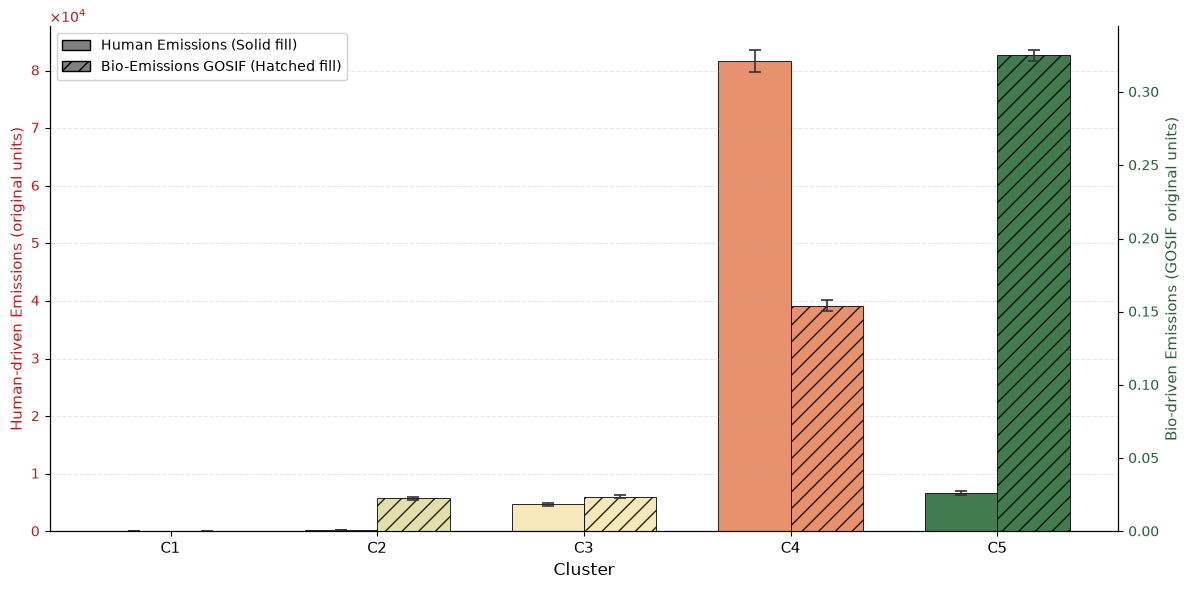

In [156]:
"""
Single-panel grouped bar plot with dual Y-axes (Emissions on left, GOSIF on right).
Both axes use a linear scale starting exactly at 0 to keep the bars aligned perfectly.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\darja\Complexity72h\complexity72_2026\clustering\co-occurrence-clusters.csv")

COMPONENT_COLS = [c for c in df.columns if c.startswith("component_")]
N_CLUSTERS = len(COMPONENT_COLS)

# ── Melt to long format ──────────────────────────────────────────────────────
df_long = df.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df_long = df_long[df_long["member"] == 1].copy()
df_long["cluster_id"] = df_long["component"].str.extract(r"(\d+)$").astype(int)

# ── Step 1: Spatial mean per (cluster, year) ──────────────────────────────────
annual_means = (
    df_long.groupby(["cluster_id", "time"])[["emission", "gosif"]]
    .mean()
    .reset_index()
)

# ── Step 2: Temporal mean & std deviation across 10 years ────────────────────
summary_stats = (
    annual_means.groupby("cluster_id")[["emission", "gosif"]]
    .agg(["mean", "std"])
    .reset_index()
)

clusters = sorted(summary_stats["cluster_id"].unique())
n = len(clusters)

# ── Step 3: Calculate Cluster Dominance for the Colormap ──────────────────────
c_means_emission = summary_stats[("emission", "mean")].values
c_means_gosif = summary_stats[("gosif", "mean")].values

emin, emax = c_means_emission.min(), c_means_emission.max()
gmin, gmax = c_means_gosif.min(), c_means_gosif.max()

enorm = (c_means_emission - emin) / (emax - emin) if emax != emin else c_means_emission
gnorm = (c_means_gosif - gmin) / (gmax - gmin) if gmax != gmin else c_means_gosif

cluster_dominance = enorm - gnorm

# ── Recreate the EXACT Map Colormap ──────────────────────────────────────────
NULL_GRAY = "gray"
colors_muted = ["#255F38", "green", "#FFE8B4", "#E68457", "#BE1A1A"]
cmap = mcolors.LinearSegmentedColormap.from_list("muted_div", colors_muted)
norm = mcolors.Normalize(vmin=-1, vmax=1)

plot_colors = []
for idx, c in enumerate(clusters):
    if c == 1:  
        plot_colors.append(NULL_GRAY)
    else:
        dom_val = cluster_dominance[idx]
        plot_colors.append(cmap(norm(dom_val)))

# ── Plotting (Single Panel, Dual Axis) ────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()  # Instantiate secondary y-axis sharing the same x-axis

#fig.suptitle(
#    "Per-cluster 10-year mean distributions (Side-by-Side)\n"
#    "Bars show the decade mean of spatial averages | Error bars show ±1 standard deviation across years",
#    fontsize=13, y=0.98,
#)

# Grouped bar configurations
positions = np.arange(n)
bar_width = 0.35

# 1. Left Axis: Human-driven Emissions (Linear Scale, Solid Fill)
emission_means = summary_stats[("emission", "mean")].values
emission_stds = summary_stats[("emission", "std")].values

bars1 = ax1.bar(
    positions - bar_width/2,
    emission_means,
    yerr=emission_stds,
    width=bar_width,
    color=plot_colors,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    capsize=4,
    error_kw=dict(ecolor="#333333", lw=1.2, capthick=1.2),
    label="Human-driven Emissions (Solid)"
)

# Force axis to start exactly at zero
ax1.set_ylim(bottom=0)
ax1.set_ylabel("Human-driven Emissions (original units)", fontsize=11, color="#BE1A1A")
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style="sci", axis="y", scilimits=(-3, 3))
ax1.tick_params(axis='y', labelcolor="#BE1A1A")

# 2. Right Axis: Bio-driven Emissions / GOSIF (Linear Scale, Hatched Fill)
gosif_means = summary_stats[("gosif", "mean")].values
gosif_stds = summary_stats[("gosif", "std")].values

bars2 = ax2.bar(
    positions + bar_width/2,
    gosif_means,
    yerr=gosif_stds,
    width=bar_width,
    color=plot_colors,
    hatch="//",       # Diagonal shading pattern to distinguish from human emissions
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    capsize=4,
    error_kw=dict(ecolor="#333333", lw=1.2, capthick=1.2),
    label="Bio-driven Emissions (Hatched)"
)

# Force axis to start exactly at zero
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Bio-driven Emissions (GOSIF original units)", fontsize=11, color="#255F38")
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style="sci", axis="y", scilimits=(-3, 3))
ax2.tick_params(axis='y', labelcolor="#255F38")

# ── X-Axis and Aesthetics ────────────────────────────────────────────────────
ax1.set_xticks(positions)
ax1.set_xticklabels([f"C{c}" for c in clusters], fontsize=11)
ax1.set_xlabel("Cluster", fontsize=12)

# Grid and Spines cleanup
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Clean custom legends to describe the styling distinction
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Human Emissions (Solid fill)"),
    Patch(facecolor="gray", edgecolor="black", hatch="//", label="Bio-Emissions GOSIF (Hatched fill)")
]
ax1.legend(handles=legend_elements, loc="upper left", framealpha=0.9)

#plt.savefig("cluster_dual_axis_barplot.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [158]:
plot_colors

['gray',
 (np.float64(0.8666666666666667),
  np.float64(0.8554248366013072),
  np.float64(0.611764705882353),
  np.float64(1.0)),
 (np.float64(0.9607843137254902),
  np.float64(0.8938100730488274),
  np.float64(0.6782006920415226),
  np.float64(1.0)),
 (np.float64(0.8927335640138409),
  np.float64(0.4931949250288351),
  np.float64(0.3271049596309112),
  np.float64(1.0)),
 (np.float64(0.12233756247597079),
  np.float64(0.3928489042675894),
  np.float64(0.1851595540176855),
  np.float64(1.0))]

In [155]:
mcolors.to_hex('green')

'#008000'

Saved: cluster_map.png with high-contrast transitional star markers


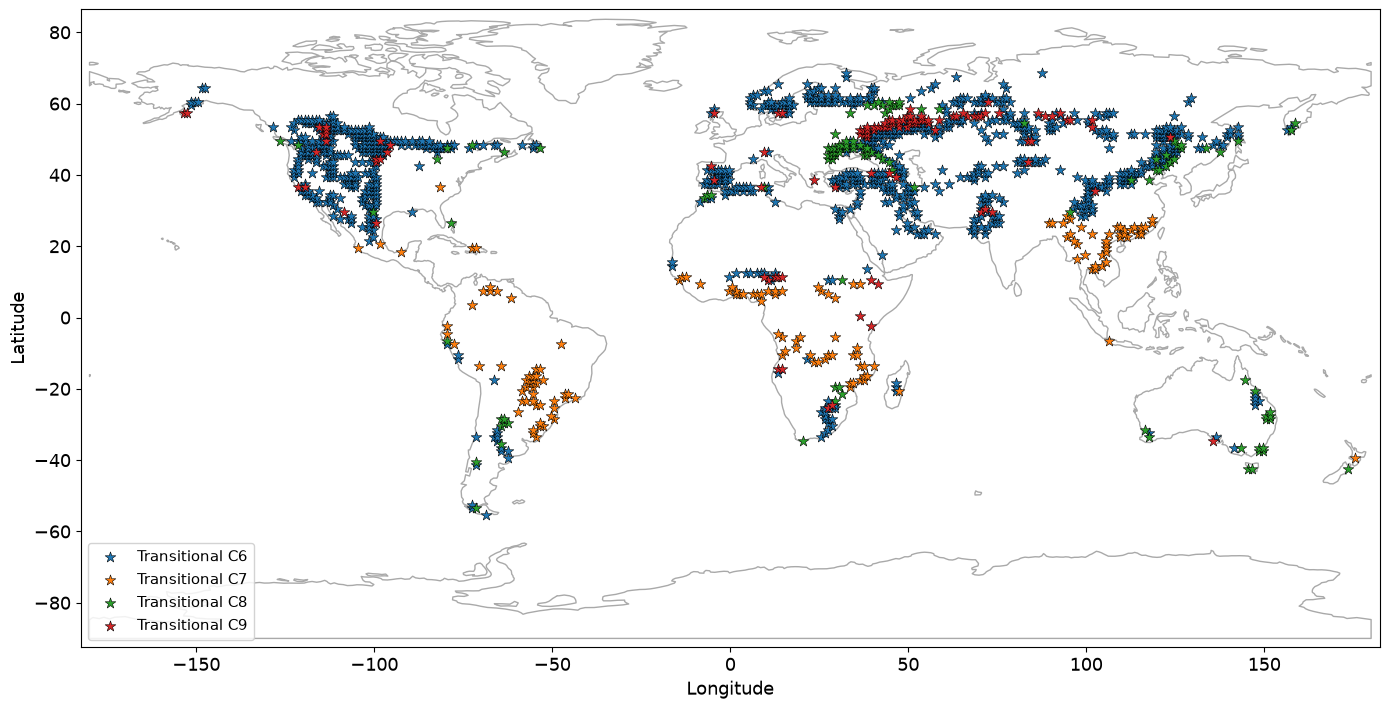

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

df2 = pd.read_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/sophia.csv")
df2.drop(columns=["component_1", "component_2", "component_3", "component_4", "component_5"], inplace=True)

COMPONENT_COLS = [c for c in df2.columns if c.startswith("component_")]
# ── Melt: one row per (lat, lon, time, cluster_id) for membership == 1 ────────
df2_long = df2.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df2_long = df2_long[df2_long["member"] == 1].copy()
df2_long["cluster_id"] = df2_long["component"].str.extract(r"(\d+)$").astype(int)
 
# ── One row per unique lat-lon ────────────────────────────────────────────────
point_cluster2 = (
    df2_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)

# ── Load world borders and clip to extent ─────────────────────────────────────
world = load_world()
world = world.cx[lon_min:lon_max, lat_min:lat_max]   # spatial clip

# Force re-execution by re-running the full map cell
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("white")

world.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgray",
    linewidth=1,
    zorder=1,
)

# ── HIGH-CONTRAST QUALITATIVE COLORS FOR TRANSITIONAL REGIONS ────────────────
unique_clusters = sorted(point_cluster2["cluster_id"].dropna().unique())
NULL_GRAY = "gray"

# Using a high-contrast qualitative color palette (tab10 gives bright distinct colors)
qualitative_cmap = plt.get_cmap("tab10")

# Generate distinct colors for each component ID
cluster_colors = {}
for i, c_id in enumerate(unique_clusters):
    if c_id == 1:
        cluster_colors[c_id] = NULL_GRAY
    else:
        # Pull distinct bright colors from the categorical map
        cluster_colors[c_id] = qualitative_cmap(i % 10)

# ── PLOT DISSIMILAR COMPONENT IDS WITH HIGH-CONTRAST STAR MARKERS ─────────────
for c_id in unique_clusters:
    cluster_mask = point_cluster2["cluster_id"] == c_id
    
    if cluster_mask.any():
        ax.scatter(
            point_cluster2.loc[cluster_mask, "lon"], 
            point_cluster2.loc[cluster_mask, "lat"],
            color=cluster_colors[c_id],
            marker="*",         # Clear star marker
            s=65,               # Bumped size slightly larger to visually 'pop' over underlying map features
            alpha=1.0,
            zorder=5 if c_id != 1 else 3, 
            linewidths=0.4,
            edgecolors="black", # Bold black border ensures the stars completely pop out
            label=f"Transitional C{c_id}"
        )

# ── Custom Distinct Legend ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=11, framealpha=0.85)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude",  fontsize=13)
ax.tick_params(labelsize=13)

plt.tight_layout()
print("Saved: cluster_map.png with high-contrast transitional star markers")
plt.show()

C:\Users\darja\AppData\Local\Temp\ipykernel_29204\929997435.py:93: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Saved: cluster_map.png with background dominance and transitional stars overlay


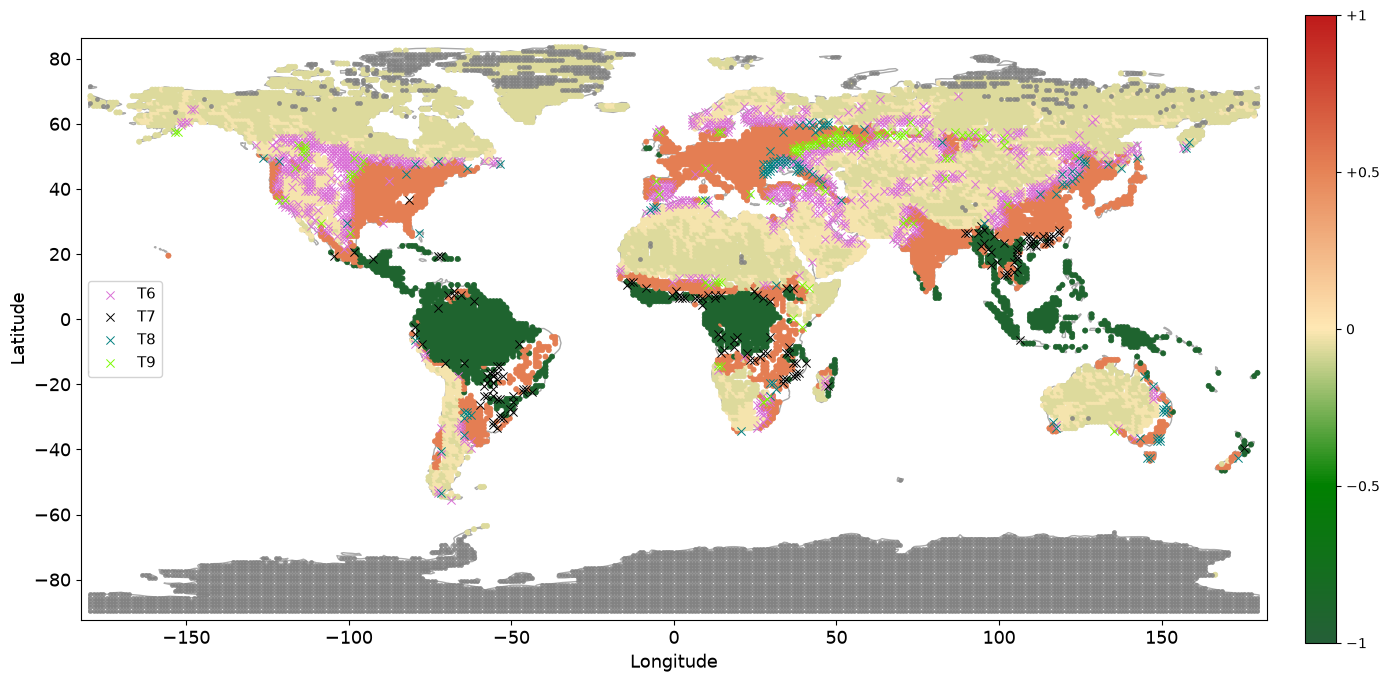

In [169]:
import importlib
import sys
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# ── Load and Process Transitional Data (Sophia) ──────────────────────────────
df2 = pd.read_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/sophia.csv")
df2.drop(columns=["component_1", "component_2", "component_3", "component_4", "component_5"], inplace=True)

COMPONENT_COLS = [c for c in df2.columns if c.startswith("component_")]

# Melt to long format and keep active assignments
df2_long = df2.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df2_long = df2_long[df2_long["member"] == 1].copy()
df2_long["cluster_id"] = df2_long["component"].str.extract(r"(\d+)$").astype(int)
 
# Get unique lat-lon rows for transitional points
point_cluster2 = (
    df2_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)

# ── Base Map Configuration (Muted Diverging) ──────────────────────────────────
NULL_GRAY = "gray"
colors_muted = ["#255F38", "green", "#FFE8B4", "#E68457", "#BE1A1A"]
cmap = mcolors.LinearSegmentedColormap.from_list("muted_div", colors_muted)
cmap.set_bad(color=NULL_GRAY)
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Force re-execution by re-running the full map cell
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("white")

world.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgray",
    linewidth=1,
    zorder=1,
)

# ── BASE LAYER: BACKGROUND DOMINANCE CLUSTERS ─────────────────────────────────
valid_mask = point_cluster["dominance"].notna()
null_mask = ~valid_mask

# 1. Plot background valid points
sc = ax.scatter(
    point_cluster.loc[valid_mask, "lon"], 
    point_cluster.loc[valid_mask, "lat"],
    c=point_cluster.loc[valid_mask, "dominance"],
    cmap=cmap, norm=norm,
    s=14, alpha=1,
    zorder=2, linewidths=0.5, # Reduced zorder to keep background underneath
)

# 2. Plot background null points
if null_mask.any():
    ax.scatter(
        point_cluster.loc[null_mask, "lon"], 
        point_cluster.loc[null_mask, "lat"],
        color=NULL_GRAY,
        s=12, alpha=0.85,
        zorder=2, linewidths=0,
    )

# ── TOP LAYER: TRANSITIONAL REGIONS OVERLAY (HIGH-CONTRAST STARS) ─────────────
unique_trans_clusters = sorted(point_cluster2["cluster_id"].dropna().unique())
# Use your explicit custom high-contrast color palette
custom_trans_colors = ['orchid', 'black', 'teal', 'lawngreen']

for i, c_id in enumerate(unique_trans_clusters):
    cluster_mask = point_cluster2["cluster_id"] == c_id
    
    # Cycle safely through your custom list of colors
    trans_color = custom_trans_colors[i % len(custom_trans_colors)]
    
    # Convert color to hex to easily check if it's the tab10 orange ("#ff7f0e")
    # If it matches, switch it to a crisp purple ("#9467bd" or "purple")
    if mcolors.to_hex(trans_color) == "#ff7f0e":
        trans_color = "purple"
    
    if cluster_mask.any():
        ax.scatter(
            point_cluster2.loc[cluster_mask, "lon"], 
            point_cluster2.loc[cluster_mask, "lat"],
            color=trans_color,
            marker="x",
                     # Crisp star marker
            s=35,               # Made larger to stand out distinctly over background points
            alpha=1.0,
            zorder=5,           # High zorder guarantees it draws on top of everything
            linewidths=0.7,
            edgecolors="black", # Black outline keeps the star visible over any background color
            label=f"T{c_id}"
        )

# ── Colorbar and Layout Aesthetics ────────────────────────────────────────────
cbar = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax, orientation="vertical", fraction=0.025, pad=0.03,
)
#cbar.set_label(
#    r"DSe_norm-DSb_norm)",
#    fontsize=11,
#)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["−1", "−0.5", "0", "+0.5", "+1"])

# Add legend to distinguish the transitional cluster stars
ax.legend(loc="center left", fontsize=11, framealpha=0.85)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude",  fontsize=13)
ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig("cluster_map_transitional.png", dpi=150, bbox_inches="tight")
print("Saved: cluster_map.png with background dominance and transitional stars overlay")
plt.show()

In [167]:
mcolors.to_hex('gray')

'#808080'

Saved: cluster_map_simplified.png with black background, white persistent clusters, and gray transitional markers.


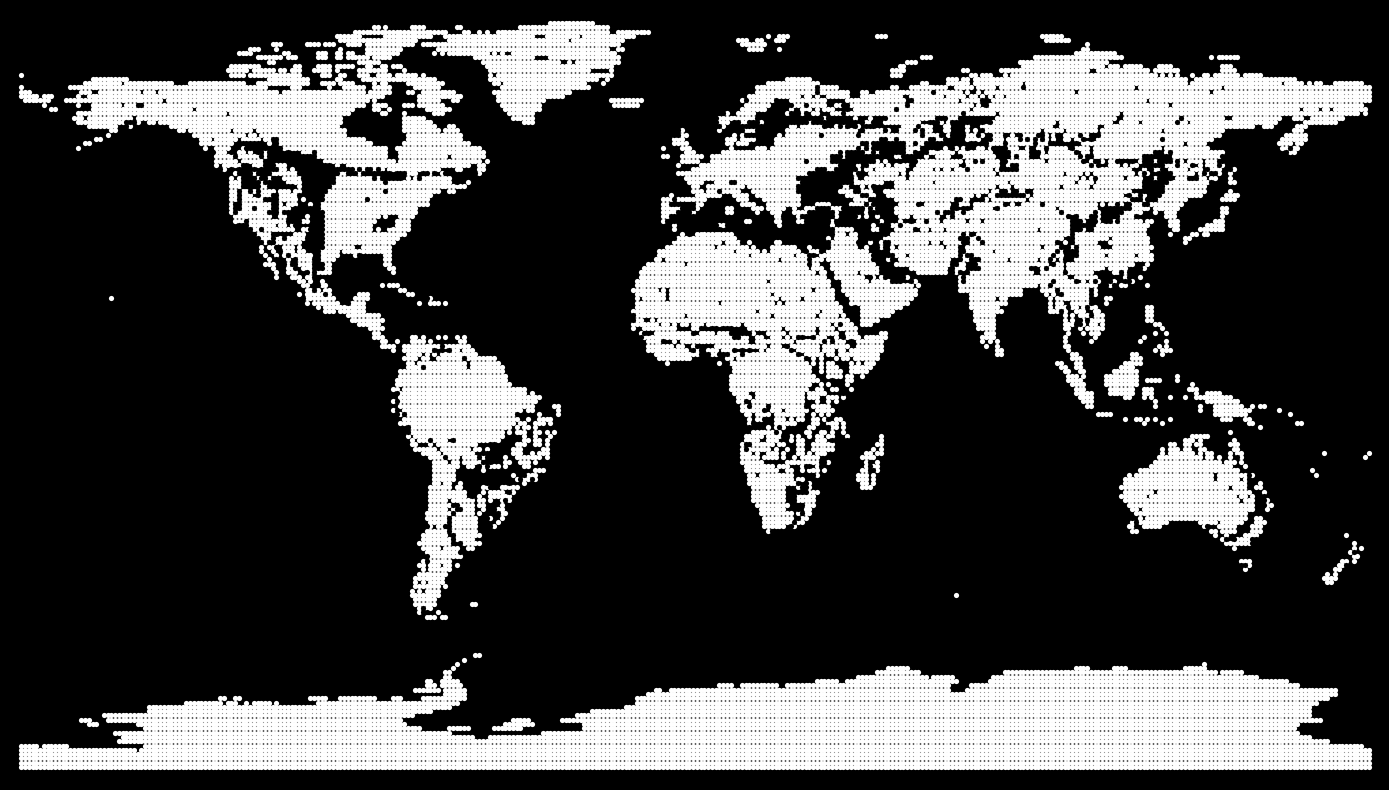

In [166]:


# ── Load and Process Transitional Data (Sophia) ──────────────────────────────
df2 = pd.read_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/sophia.csv")
df2.drop(columns=["component_1", "component_2", "component_3", "component_4", "component_5"], inplace=True)

COMPONENT_COLS = [c for c in df2.columns if c.startswith("component_")]

# Melt to long format and keep active assignments
df2_long = df2.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df2_long = df2_long[df2_long["member"] == 1].copy()
df2_long["cluster_id"] = df2_long["component"].str.extract(r"(\d+)$").astype(int)
 
# Get unique lat-lon rows for transitional points
point_cluster2 = (
    df2_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)

# ── Setup Simplified High-Contrast Figure ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("black")  # Figure outer padding black
ax.set_facecolor("black")         # Plot canvas area black

# (Geopandas world map plotting removed entirely as requested)

# ── BASE LAYER: ALL BACKGROUND CLUSTERS UNIFIED TO WHITE ──────────────────────
# Plotting both valid and null background points as clean white
ax.scatter(
    point_cluster["lon"], 
    point_cluster["lat"],
    color="white",
    s=14, 
    alpha=1,
    zorder=2, 
    linewidths=0,
)

# ── TOP LAYER: TRANSITIONAL REGIONS OVERLAY (GRAY PLOT OVERLAY) ───────────────
unique_trans_clusters = sorted(point_cluster2["cluster_id"].dropna().unique())

for c_id in unique_trans_clusters:
    cluster_mask = point_cluster2["cluster_id"] == c_id
    
    if cluster_mask.any():
        ax.scatter(
            point_cluster2.loc[cluster_mask, "lon"], 
            point_cluster2.loc[cluster_mask, "lat"],
            color="black",       # Transitional clusters simplified to gray
            s=14, 
            alpha=1,
            zorder=2, 
            linewidths=0,
        )

# ── Cleanup Layout and Map Borders ──────────────────────────────────────────
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Turn off all axis lines, labels, ticks, and grids for an entirely clean image
ax.axis("off")

plt.tight_layout()
plt.savefig("cluster_map_simplified.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor='none')
print("Saved: cluster_map_simplified.png with black background, white persistent clusters, and gray transitional markers.")
plt.show()